# Исследование стартапов

## Введение

**Автор:** Шагунов А.П.  
**Дата:** 05.05.2026

## Цель и задачи  

**Цель:** Провести исследовательский анализ венчурных стартапов, чтобы выявить закономерности их финансирования и оценить перспективы выхода на рынок с покупкой и развитием компаний.  

**Задачи:**
1. Загрузить данные и познакомиться с их содержимым.
2. Провести предобработку данных.
3. Исследовать динамику и структуру финансирования стартапов
4. Сформулировать выводы и рекомендации по проведённому анализу, ответить на вопросы, важные для оценки инвестиционных стратегий.

## Данные

Для анализа поступили исторические данные о компаниях, объёмах и типах привлечённых инвестиций, а также с дополнительной статистикой по возвратам средств. Данные состоят из двух датасетов:

- `cb_investments.csv` — информация о компаниях и состоявшемся финансировании;
- `cb_returns.csv` —  информация об объёмах возвратов по годам и типам финансирования в миллионах долларов.

### Описание датасета `cb_investments`

* `name` — название компании.
* `homepage_url` — ссылка на сайт компании.
* `category_list` — категории, в которых работает компания. Указываются через `|`.
* `market` — основной рынок или отрасль компании.
* `funding_total_usd` — общий объём привлечённых инвестиций в долларах США.
* `status` — текущий статус компании, например `operating`, `closed` и так далее.
* `country_code` — код страны, например USA.
* `state_code` — код штата или региона, например, CA.
* `region` — регион, например, SF Bay Area.
* `city` — город, в котором расположена компания.
* `funding_rounds` — общее число раундов финансирования.
* `participants` — число участников в раундах финансирования.
* `founded_at` — дата основания компании.
* `founded_month` — месяц основания в формате `YYYY-MM`.
* `founded_quarter` — квартал основания в формате `YYYY-QN`.
* `founded_year` — год основания.
* `first_funding_at` — дата первого финансирования.
* `mid_funding_at` — дата среднего по времени раунда финансирования.
* `last_funding_at` — дата последнего финансирования.
* `seed` — сумма инвестиций на посевной стадии.
* `venture` — сумма венчурных инвестиций.
* `equity_crowdfunding` — сумма, привлечённая через долевой краудфандинг.
* `undisclosed` — сумма финансирования нераскрытого типа.
* `convertible_note` — сумма инвестиций через конвертируемые займы.
* `debt_financing` — сумма долгового финансирования.
* `angel` — сумма инвестиций от бизнес-ангелов.
* `grant` — сумма полученных грантов.
* `private_equity` — сумма инвестиций в виде прямых (частных) вложений.
* `post_ipo_equity` — сумма финансирования после IPO.
* `post_ipo_debt` — сумма долгового финансирования после IPO.
* `secondary_market` — сумма сделок на вторичном рынке.
* `product_crowdfunding` — сумма, привлечённая через продуктовый краудфандинг.
* `round_A` — `round_H` — сумма инвестиций в соответствующем раунде.

### Описание датасета `cb_returns`

* `year` — год возврата средств.
* `seed` — сумма возвратов от посевных инвестиций.
* `venture` — сумма возвратов от венчурных инвестиций.
* `equity_crowdfunding` — сумма, возвращённая по долевому краудфандингу.
* `undisclosed` — сумма возвратов нераскрытого типа.
* `convertible_note` — сумма возвратов через конвертируемые займы.
* `debt_financing` — сумма возвратов от долгового финансирования.
* `angel` — сумма возвратов бизнес-ангелам.
* `grant` — сумма возвратов по грантам.
* `private_equity` — сумма возвратов прямых (частных) вложений.
* `post_ipo_equity` — сумма возвратов от IPO.
* `post_ipo_debt` — сумма возвратов от долгового IPO.
* `secondary_market` — сумма возвратов от сделок на вторичном рынке.
* `product_crowdfunding` — сумма возвратов по продуктовому краудфандингу.

## Структура проекта

1. Знакомство с данными: загрузка и предобработка
2. Предобработка данных.
3. Исследовательский анализ данных.
4. Итоговые выводы.
---

## 1. Знакомство с данными: загрузка и предобработка

### 1.1. Вывод общей информации

Начнём с загрузки библиотек и датасетов `cb_investments` и `cb_returns`. Будем использовать pandas и библиотеки визуализации данных matplotlib и seaborn, а также phik для построения матрицы корреляции. Данные датасетов сохраним в двух
переменных: `investments_df` и `returns_df`.

In [1]:
# Импортируем библиотеки
import pandas as pd

# Загружаем библиотеки для визуализации данных
import matplotlib.pyplot as plt
import seaborn as sns

# Загружаем библиотеку для расчёта коэффициента корреляции phi_k
from phik import phik_matrix

In [2]:
investments_df = pd.read_csv("https://code.s3.yandex.net/datasets/cb_investments.zip", sep=';', low_memory=False)
returns_df = pd.read_csv("https://code.s3.yandex.net/datasets/cb_returns.csv")

Познакомимся с данными обоих датасетов — выведем первые и последние строки методами `head()` и `tail()`, а также информацию о датафрейме методом `info()`:

In [3]:
pd.set_option('display.max_columns', None)  # показать все столбцы
investments_df.head(5)

,name,homepage_url,category_list,market,funding_total_usd,status,country_code,state_code,region,city,funding_rounds,participants,founded_at,founded_month,founded_quarter,founded_year,first_funding_at,mid_funding_at,last_funding_at,seed,venture,equity_crowdfunding,undisclosed,convertible_note,debt_financing,angel,grant,private_equity,post_ipo_equity,post_ipo_debt,secondary_market,product_crowdfunding,round_A,round_B,round_C,round_D,round_E,round_F,round_G,round_H
0,Harvard University,http://harvard.edu,|Education|,Education,"9,00,00,000",operating,USA,MA,Boston,Cambridge,1.0,NaN,1636-09-08,NaN,NaN,1636.0,2014-01-06,NaN,2014-01-06,0.0,0.0,0.0,0.0,0.0,0.0,0.0,90000000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,University of New Brunswick,http://www.unb.ca,NaN,NaN,"20,00,000",operating,NaN,NaN,NaN,NaN,1.0,NaN,1785-01-01,NaN,NaN,1785.0,2014-05-15,NaN,2014-05-15,0.0,2000000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,DuPont,http://www.dupont.com,|Business Services|Agriculture|Automotive|Inve...,Business Services,"90,00,000",operating,USA,DE,"Wilmington, Delaware",Wilmington,1.0,1.0,1802-07-19,NaN,NaN,1802.0,2009-07-02,2009-07-02,2009-07-02,0.0,9000000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,University of Michigan,http://www.umich.edu/,|Education|,Education,"77,00,000",operating,USA,MI,Detroit,Ann Arbor,3.0,0.0,1817-01-01,NaN,NaN,1817.0,2013-11-21,2013-11-21,2014-11-03,0.0,0.0,0.0,1600000.0,0.0,0.0,0.0,6100000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,Case Western Reserve University,http://www.case.edu,|Education|,Education,"5,40,000",operating,USA,OH,Cleveland,Cleveland,1.0,NaN,1826-01-01,NaN,NaN,1826.0,2014-01-14,NaN,2014-01-14,0.0,0.0,0.0,0.0,0.0,0.0,0.0,540000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [4]:
investments_df.tail()

,name,homepage_url,category_list,market,funding_total_usd,status,country_code,state_code,region,city,funding_rounds,participants,founded_at,founded_month,founded_quarter,founded_year,first_funding_at,mid_funding_at,last_funding_at,seed,venture,equity_crowdfunding,undisclosed,convertible_note,debt_financing,angel,grant,private_equity,post_ipo_equity,post_ipo_debt,secondary_market,product_crowdfunding,round_A,round_B,round_C,round_D,round_E,round_F,round_G,round_H
54289,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
54290,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
54291,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
54292,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
54293,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
investments_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54294 entries, 0 to 54293
Data columns (total 40 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   name                  49437 non-null  object 
 1   homepage_url          45989 non-null  object 
 2   category_list         45477 non-null  object 
 3    market               45477 non-null  object 
 4    funding_total_usd    49438 non-null  object 
 5   status                48124 non-null  object 
 6   country_code          44165 non-null  object 
 7   state_code            30161 non-null  object 
 8   region                44165 non-null  object 
 9   city                  43322 non-null  object 
 10  funding_rounds        49438 non-null  float64
 11  participants          30473 non-null  float64
 12  founded_at            38554 non-null  object 
 13  founded_month         38482 non-null  object 
 14  founded_quarter       38482 non-null  object 
 15  founded_year       

In [6]:
returns_df

,year,seed,venture,equity_crowdfunding,undisclosed,convertible_note,debt_financing,angel,grant,private_equity,post_ipo_equity,post_ipo_debt,secondary_market,product_crowdfunding
0,2000,16.70,55.40,0.00,78.21,0.00,8.66,6.43,0.0,0.00,0.94,0.00,0.20,0.00
1,2001,2.88,23.49,0.00,21.50,0.01,4.49,1.18,0.0,0.00,0.46,0.00,0.46,0.00
2,2002,6.59,209.42,0.00,25.77,0.02,3.42,3.41,0.0,1.51,0.34,0.00,0.06,0.00
3,2003,7.74,233.86,0.00,9.40,0.01,1.09,3.41,0.0,1.62,2.11,0.00,0.08,0.00
4,2004,9.93,555.90,0.00,33.19,0.01,13.55,9.18,0.0,2.19,3.38,0.00,0.55,0.00
5,2005,26.60,2628.92,0.00,9.51,0.02,35.09,31.06,0.0,2.40,3.51,0.00,0.05,0.00
6,2006,61.81,3100.18,0.19,46.74,1.78,113.21,47.75,0.0,16.67,20.58,0.00,0.12,0.00
7,2007,70.41,3585.37,0.01,55.37,3.22,125.68,164.51,0.0,88.81,24.36,0.00,0.57,0.00
8,2008,89.72,2717.02,0.03,41.02,1.71,397.54,102.83,0.0,130.38,84.28,0.00,0.47,0.00
9,2009,160.21,2501.29,0.18,37.50,2.25,394.10,97.21,0.0,203.70,76.76,0.00,0.12,0.02


In [7]:
returns_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   year                  15 non-null     int64  
 1   seed                  15 non-null     float64
 2   venture               15 non-null     float64
 3   equity_crowdfunding   15 non-null     float64
 4   undisclosed           15 non-null     float64
 5   convertible_note      15 non-null     float64
 6   debt_financing        15 non-null     float64
 7   angel                 15 non-null     float64
 8   grant                 15 non-null     float64
 9   private_equity        15 non-null     float64
 10  post_ipo_equity       15 non-null     float64
 11  post_ipo_debt         15 non-null     float64
 12  secondary_market      15 non-null     float64
 13  product_crowdfunding  15 non-null     float64
dtypes: float64(13), int64(1)
memory usage: 1.8 KB


Датасет `investments_df.csv` содержит 40 столбцов и 54294 строк, в которых представлена общая информация о компаниях и состоявшемся финансировании. После первичного анализа данных можно сделать следующие выводы:

- Названия столбцов соответствуют snake case, но в столбцах `market` и `funding_total_usd` есть пробел первым символом. Необходимо привести столбцы в единый стиль. 
- Данные содержат числовые и текстовые значения, которые хранятся в типах данных `float64` и `object`.<br>
Столбец `funding_total_usd` имеет тип `object`, но содержит объём привлечённых инвестиций, требуется корректировка типа данных на `float64`.<br>
Столбцы с датами `founded_at`, `first_funding_at`, `mid_funding_at`, `last_funding_at` имеют тип `object`. Необходима корректировка на `datetime`.
- Во всех столбцах содержатся пропуски, в конце датафрейма содержатся пропуски во всех столбцах.
- Судя по первому знакомству с данными, значения в столбцах соответствуют своему описанию.

Датасет `returns_df.csv` содержит 14 столбцов и 15 строк, в которых представлена информация об объёмах возвратов по годам и типам финансирования в миллионах долларов. По аналогии с предыдущим датасетом можно отметить, что:

- Названия столбцов соответствуют snake case.
- Типы данных соответствуют содержимому.
- В данных нет пропусков.
- Значения в столбцах соответствуют описанию.

Первичное знакомство показывает, что данные приемлемого качества. Есть пропущенные значения, но скорее всего они связаны ошибкой в данных и пустыми строками. Данные соответствуют описанию и выглядят корректными.

### 1.2. Предобработка данных

Скорретируем названия столбцов и уберем лишние пробелы в начале названий столбцов `market` и `funding_total_usd`. 

In [8]:
investments_df.columns = investments_df.columns.str.strip()

Проверим, что названия скорретированы.

In [9]:
print(investments_df.columns.tolist())

['name', 'homepage_url', 'category_list', 'market', 'funding_total_usd', 'status', 'country_code', 'state_code', 'region', 'city', 'funding_rounds', 'participants', 'founded_at', 'founded_month', 'founded_quarter', 'founded_year', 'first_funding_at', 'mid_funding_at', 'last_funding_at', 'seed', 'venture', 'equity_crowdfunding', 'undisclosed', 'convertible_note', 'debt_financing', 'angel', 'grant', 'private_equity', 'post_ipo_equity', 'post_ipo_debt', 'secondary_market', 'product_crowdfunding', 'round_A', 'round_B', 'round_C', 'round_D', 'round_E', 'round_F', 'round_G', 'round_H']


Для начала уберем в столбце `funding_total_usd` выделение разрядов и приведем его к числовому типу. Будем использовать метод `pd.to_numeric` с аргументом `downcast='integer'`.

In [10]:
investments_df['funding_total_usd'] = (
    investments_df['funding_total_usd']
    .str.replace(',', '', regex=False)  # убираем запятые разрядов
)

investments_df['funding_total_usd'] = pd.to_numeric(
    investments_df['funding_total_usd'], 
    downcast='integer',
    errors='coerce'  # некорректные значения, например "-" станут NaN вместо ошибки
)

Проверим получившийся тип данных и сами данные с помощью head()

In [11]:
investments_df['funding_total_usd'].head()

0    90000000.0
1     2000000.0
2     9000000.0
3     7700000.0
4      540000.0
Name: funding_total_usd, dtype: float64

Скорретируем тип данных в столбцах, которые хранят значения даты и времени на datetime64.

In [12]:
date_columns = ['founded_at', 'first_funding_at', 'mid_funding_at', 'last_funding_at']
for column in date_columns:
    if column in investments_df.columns:
        investments_df[column] = pd.to_datetime(investments_df[column], format='%Y-%m-%d', errors='coerce')

In [13]:
investments_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54294 entries, 0 to 54293
Data columns (total 40 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   name                  49437 non-null  object        
 1   homepage_url          45989 non-null  object        
 2   category_list         45477 non-null  object        
 3   market                45477 non-null  object        
 4   funding_total_usd     40907 non-null  float64       
 5   status                48124 non-null  object        
 6   country_code          44165 non-null  object        
 7   state_code            30161 non-null  object        
 8   region                44165 non-null  object        
 9   city                  43322 non-null  object        
 10  funding_rounds        49438 non-null  float64       
 11  participants          30473 non-null  float64       
 12  founded_at            38553 non-null  datetime64[ns]
 13  founded_month   

Устанавим столбец `year` как индекс в `returns_df` и выполним проверку. 

In [14]:
if 'year' in returns_df.columns:
    returns_df.set_index('year', inplace=True)
    print("Столбец 'year' установлен как индекс в returns_df.")
else:
    print("Ошибка установки индекса.")

Столбец 'year' установлен как индекс в returns_df.


In [15]:
returns_df.head()

,seed,venture,equity_crowdfunding,undisclosed,convertible_note,debt_financing,angel,grant,private_equity,post_ipo_equity,post_ipo_debt,secondary_market,product_crowdfunding
year,,,,,,,,,,,,,
2000,16.70,55.40,0.0,78.21,0.00,8.66,6.43,0.0,0.00,0.94,0.0,0.20,0.0
2001,2.88,23.49,0.0,21.50,0.01,4.49,1.18,0.0,0.00,0.46,0.0,0.46,0.0
2002,6.59,209.42,0.0,25.77,0.02,3.42,3.41,0.0,1.51,0.34,0.0,0.06,0.0
2003,7.74,233.86,0.0,9.40,0.01,1.09,3.41,0.0,1.62,2.11,0.0,0.08,0.0
2004,9.93,555.90,0.0,33.19,0.01,13.55,9.18,0.0,2.19,3.38,0.0,0.55,0.0


При первичном анализе мы обнаружили пропуски в столбцах `investments_df`. Узнаем их абсолютное и относительное количество.

In [16]:
pd.DataFrame({
    'Тип данных': investments_df.dtypes,
    'Пропуски, шт.': investments_df.isna().sum(),
    'Доля, %': (investments_df.isna().sum() / investments_df.shape[0] * 100).round(2)
}).sort_values('Пропуски, шт.', ascending=False)

,Тип данных,"Пропуски, шт.","Доля, %"
state_code,object,24133,44.45
mid_funding_at,datetime64[ns],24006,44.21
participants,float64,23821,43.87
founded_quarter,object,15812,29.12
founded_month,object,15812,29.12
founded_at,datetime64[ns],15741,28.99
founded_year,float64,15740,28.99
funding_total_usd,float64,13387,24.66
city,object,10972,20.21
region,object,10129,18.66


В датафрейме `investments_df` обнаружены пропуски во всех столбцах. В каждом стольце минимум 4856 пропусков. Больше всего в столбце - `state_code` — пропущено 24133 значений, это 44% данных. Скорее всего код штата или региона есть не во всех странах. Остальные пропуски связаны с тех. ошибки или отсутствием информации.

Обработаем текстовые столбцы, уберём лишние пробелы в начале и в конце строки, которые могут создавать дубликаты с помощью `str.strip()` и заполним пропуски заглушкой `unkown`.

In [17]:
text_columns = ['name', 'homepage_url', 'category_list', 'market',
             'status', 'country_code', 'state_code', 'region', 'city']

# Уберём пробелы
for col in text_columns:
    investments_df[col] = investments_df[col].str.strip()

print('Пропуски в текстовых столбцах ДО обработки:')
display(investments_df[text_columns].isna().sum())
print()

# Заполняем пропуски заглушками там, где отсутствие значения мешает анализу.
# В столбцах homepage_url и name — заглушки не нужны, оставляем NaN
fill_map = {
    'market':       'unknown',
    'status':       'unknown',
    'country_code': 'unknown',
    'state_code':   'unknown',
    'region':       'unknown',
    'city':         'unknown',
    'category_list':'unknown',
}

for col, stub in fill_map.items():
    investments_df[col] = investments_df[col].fillna(stub).str.strip()


print('Пропуски в текстовых столбцах ПОСЛЕ обработки:')
display(investments_df[text_columns].isna().sum())

Пропуски в текстовых столбцах ДО обработки:


name              4857
homepage_url      8305
category_list     8817
market            8817
status            6170
country_code     10129
state_code       24133
region           10129
city             10972
dtype: int64


Пропуски в текстовых столбцах ПОСЛЕ обработки:


name             4857
homepage_url     8305
category_list       0
market              0
status              0
country_code        0
state_code          0
region              0
city                0
dtype: int64

Обработаем полные дубликаты в данных и пропуски в `funding_total_usd`.

Избавимся от тех строк, которые не несут какой-либо информации либо не содержат данных о финансировании. 

In [18]:
rows_start = len(investments_df)
print(f'Строк до очистки: {rows_start}')

# Полные дубликаты
number_of_dupicates = investments_df.duplicated().sum()
investments_df = investments_df.drop_duplicates()
print(f'Удалено полных дубликатов: {number_of_dupicates}')

# Строки с пропуском в funding_total_usd
number_of_null_funding_total_usd = investments_df['funding_total_usd'].isna().sum()
investments_df = investments_df[investments_df['funding_total_usd'].notna()]
print(f'Удалено строк с NaN в funding_total_usd: {number_of_null_funding_total_usd}')

# Строки с нулевым финансированием
number_of_zero = (investments_df['funding_total_usd'] == 0).sum()
df = investments_df[investments_df['funding_total_usd'] > 0]
print(f'Удалено строк с нулевым финансированием: {number_of_zero}')

rows_end = len(investments_df)
print(f'\nСтрок после очистки: {rows_end}')
print(f'Удалено строк: {rows_start - rows_end} ({(rows_start - rows_end)/rows_start*100:.1f}%)')

Строк до очистки: 54294
Удалено полных дубликатов: 4855
Удалено строк с NaN в funding_total_usd: 8532
Удалено строк с нулевым финансированием: 0

Строк после очистки: 40907
Удалено строк: 13387 (24.7%)


Заполним пропуски в значениях `mid_funding_at` на основании значений в столбцах `first_funding_at` и `last_funding_at`. В качестве нового значения вместо пропусков возьмём приблизительно середину интервала между этими двумя датами.

In [19]:
# Находим строки, где mid_funding_at отсутствует,
# но есть first_funding_at и last_funding_at
mask_missing = investments_df['mid_funding_at'].isna()
mask_both    = investments_df['first_funding_at'].notna() & investments_df['last_funding_at'].notna()
mask_fill    = mask_missing & mask_both

# mid = first + (last - first) / 2
investments_df.loc[mask_fill, 'mid_funding_at'] = (
    investments_df.loc[mask_fill, 'first_funding_at']
    + (investments_df.loc[mask_fill, 'last_funding_at']
       - investments_df.loc[mask_fill, 'first_funding_at']) / 2
)

print(f'Заполнено значений mid_funding_at: {mask_fill.sum()}')

Заполнено значений mid_funding_at: 13675


Проверим размер оставшихся пропусков в столбце `mid_funding_at`.

In [20]:
numbers_of_null_mid = investments_df['mid_funding_at'].isna().sum()
percent_of_null_mid = numbers_of_null_mid / len(investments_df) * 100

print(f'Оставшихся пропусков в mid_funding_at: {numbers_of_null_mid} ({percent_of_null_mid:.1f}%)')

Оставшихся пропусков в mid_funding_at: 1 (0.0%)


Остался один пропуск в строке, для которого нет `first_funding_at`. Расчитать `mid_funding_at` невозможно. Оставим один пропуск как есть, т.к. это некритично для анализа.

In [21]:
display(df[investments_df['mid_funding_at'].isna()])

,name,homepage_url,category_list,market,funding_total_usd,status,country_code,state_code,region,city,funding_rounds,participants,founded_at,founded_month,founded_quarter,founded_year,first_funding_at,mid_funding_at,last_funding_at,seed,venture,equity_crowdfunding,undisclosed,convertible_note,debt_financing,angel,grant,private_equity,post_ipo_equity,post_ipo_debt,secondary_market,product_crowdfunding,round_A,round_B,round_C,round_D,round_E,round_F,round_G,round_H
33041,Nubank,https://www.nubank.com.br/,|Consumer Internet|Financial Services|,Financial Services,16300000.0,operating,BRA,unknown,Sao Paulo,São Paulo,2.0,NaN,2013-01-01,2013-01,2013-Q1,2013.0,NaT,NaT,2014-09-25,2000000.0,14300000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,14300000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


Оценим полноту оставшихся данных.

In [22]:
rows_original = rows_start   # переменная исползовалась в ячейке 19
rows_final    = len(df)

# Расчет отброшенных данных
print('=== Итог предобработки ===')
print(f'Исходный датасет:  {rows_original} строк')
print(f'Итоговый датасет:  {rows_final} строк')
print(f'Отброшено:         {rows_original - rows_final} строк '
      f'({(rows_original - rows_final) / rows_original * 100:.1f}%)')
print(f'Осталось:          {rows_final / rows_original * 100:.1f}% данных')
print()

# Оценка временного диапазаона оставшихся данных
print('Диапазон дат first_funding_at:')
print(f'  min: {investments_df["first_funding_at"].min().date()}')
print(f'  max: {investments_df["first_funding_at"].max().date()}')
print()
print('Диапазон дат last_funding_at:')
print(f'  min: {investments_df["last_funding_at"].min().date()}')
print(f'  max: {investments_df["last_funding_at"].max().date()}')
print()

# Оценка количества компаний, рынков и стран в оставшихся данных
number_of_unique_companies = investments_df.drop_duplicates(subset=['name', 'homepage_url']).shape[0]
print(f'Уникальных компаний (name + homepage_url): {number_of_unique_companies}')
print('Уникальных рынков (market):', investments_df['market'].nunique())
print('Уникальных стран (country_code):', investments_df['country_code'].nunique())


=== Итог предобработки ===
Исходный датасет:  54294 строк
Итоговый датасет:  40907 строк
Отброшено:         13387 строк (24.7%)
Осталось:          75.3% данных

Диапазон дат first_funding_at:
  min: 1921-09-01
  max: 2014-12-31

Диапазон дат last_funding_at:
  min: 1921-09-01
  max: 2014-12-31

Уникальных компаний (name + homepage_url): 40897
Уникальных рынков (market): 395
Уникальных стран (country_code): 111


### 1.3. Промежуточные выводы после предобработки
**Что сделано:**
1. Загружены оба датасета: `cb_investments` и `cb_returns`.
2. Названия столбцов приведены к единому snake_case.
3. `funding_total_usd` очищен от разделителей разрядов и конвертирован в `float64`.
4. Столбцы дат конвертированы из `object` в `datetime64`.
5. В `cb_returns` столбец `year` стал индексом.
6. Пропуски в текстовых полях (`name`, `homepage_url`, `category_list`, `market`, `status`, `country_code`, `state_code`, `region`, `city`) заполнены заглушкой `'unknown'`.
7. Удалены полные дубликаты, строки без суммы финансирования (NaN и 0).
8. Пропуски в `mid_funding_at` заполнены серединой интервала `[first_funding_at, last_funding_at]`.

**Оценка полноты:**
- Отброшено 13387 строк (25%) — преимущественно строки без данных о сумме финансирования.
- Оставшихся 75% данных достаточно для решения задач проекта: это почти 41 тыс. уникальных компаний, временной диапазон широкий (1921-2014гг.), данные охватывают 111 стран.

## 2. Инжиниринг признаков


### 2.1. Группы по срокам финансирования

Разделим все компании на три группы:
1. Единичное финансирование — был всего один раунд финансирования.
2. Срок финансирования до года — между первым и последним раундом финансирования прошло не более года.
3. Срок финансирования более года.

И создадим два графика:
1. По количеству компаний: покажем, какой процент от общего числа компаний относится к каждой из трёх групп.
2. По объёму инвестиций: отобразим, какую долю от общего объёма привлечённых средств получила каждая группа.

In [23]:
# Вычисляем разницу между последним и первым раундом в днях
investments_df['funding_duration_days'] = (
    investments_df['last_funding_at'] - investments_df['first_funding_at']
).dt.days

# Классифицируем компании по группам с помощью функции
def classify_funding_period(row):
    if row['funding_rounds'] == 1:
        return 'Единичное финансирование'
    elif row['funding_duration_days'] <= 365:
        return 'Срок финансирования до года'
    else:
        return 'Срок финансирования более года'

investments_df['funding_group'] = investments_df.apply(classify_funding_period, axis=1)

print('Распределение по группам:')
display(investments_df['funding_group'].value_counts())

Распределение по группам:


Единичное финансирование          24113
Срок финансирования более года    12293
Срок финансирования до года        4501
Name: funding_group, dtype: int64

In [24]:
colors = {
    'Единичное финансирование': '#4C72B0',
    'Срок финансирования до года': '#DD8452',
    'Срок финансирования более года': '#55A868',
}

# Данные для графиков
group_counts  = investments_df['funding_group'].value_counts()
group_funding = investments_df.groupby('funding_group')['funding_total_usd'].sum()

# Общий порядок категорий
order = ['Единичное финансирование', 'Срок финансирования до года', 'Срок финансирования более года']
group_counts  = group_counts.reindex(order)
group_funding = group_funding.reindex(order)

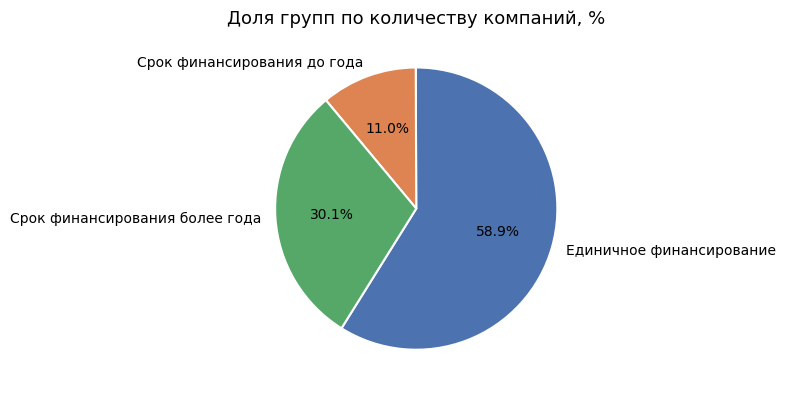

In [25]:
fig, ax = plt.subplots(figsize=(7, 6))

ax.pie(
    group_counts,
    labels=order,
    colors=[colors[g] for g in order],
    autopct='%1.1f%%',
    startangle=238,
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5}
)
ax.set_title('Доля групп по количеству компаний, %', fontsize=13)

plt.tight_layout()
plt.show()

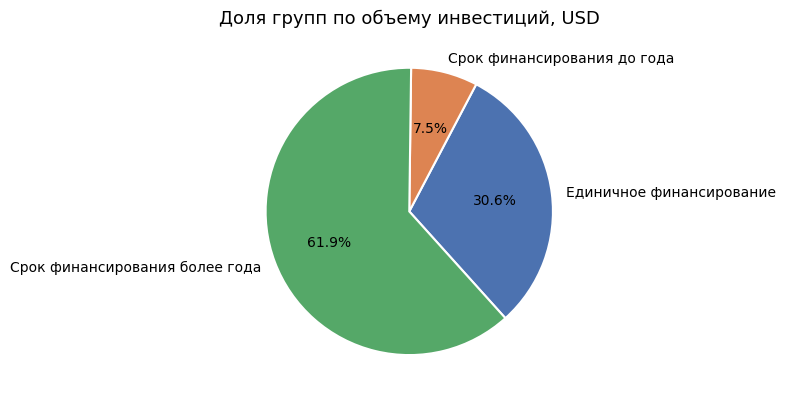

In [26]:
fig, ax = plt.subplots(figsize=(7, 6))

ax.pie(
    group_funding,
    labels=order,
    colors=[colors[g] for g in order],
    autopct='%1.1f%%',
    startangle=312,
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5}
)
ax.set_title('Доля групп по объему инвестиций, USD', fontsize=13)

plt.tight_layout()
plt.show()

**Промежуточные выводы:**
- Большинство компаний получали единичное финансирование (58,9%), на втором месте более года (30,1%) и на третьем до года (11,0%).
- При этом компании с сроком финансирования более года получают больше инвестиций (61,9% от всего объема), на втором месте компании с единичным финансированием (30,6%), на третьем месте группа сроком финанисрования до года (7,5%). 
- Группа «до года» наименьшая и по количеству компаний и по объему инветисций. Получается, что инвесторы либо делают один раунд, либо сопровождают компанию длительное время.
- Одиночные раунды встречаются чаще, но в среднем меньше по размеру инвестиций.

### 2.2 Выделение средних и нишевых сегментов рынка

В столбце `market` указан сегмент рынка. Рассчитаем, как часто в датасете встречается каждый из сегментов. Сегменты, к которым относится более 120 компаний, отнесем к массовым, сегменты, в которые входит от 35 до 120 включительно, отнесем к средним, а сегменты до 35 компаний отнесем к нишевым. Рассчитаем, сколько сегментов попадает в каждую из категорий.

In [27]:
# Считаем количество компаний в каждом сегменте
pd.set_option('display.max_rows', None)
market_counts = investments_df['market'].value_counts()
display(market_counts)

Software                              4812
Biotechnology                         3590
unknown                               2503
Mobile                                2344
E-Commerce                            1866
Curated Web                           1693
Enterprise Software                   1381
Health Care                           1185
Clean Technology                      1180
Games                                 1117
Advertising                           1107
Hardware + Software                   1062
Social Media                          1003
Health and Wellness                    873
Education                              844
Finance                                828
Analytics                              667
Manufacturing                          596
Security                               567
Semiconductors                         484
Web Hosting                            424
Consulting                             349
Hospitality                            336
Travel     

In [28]:
market_counts.describe().round(0)

count     395.0
mean      104.0
std       405.0
min         1.0
25%         1.0
50%         3.0
75%        48.0
max      4812.0
Name: market, dtype: float64

In [29]:
# Посчитаем количество уникальных сегментов
unique_markets = investments_df['market'].nunique()

# Классифицируем сегменты
def classify_market(count):
    if count > 120:
        return 'Массовый'
    elif count >= 35:
        return 'Средний'
    else:
        return 'Нишевый'

market_category = market_counts.apply(classify_market)

# Считаем количество и долю сегментов по категориям
category_stats = (
    market_category
    .value_counts()
    .rename('Количество сегментов, шт.')
    .to_frame()
)
category_stats['Доля, %'] = (category_stats['Количество сегментов, шт.'] / unique_markets * 100).round(1)

print('Количество и доля сегментов по категориям:')
display(category_stats)

Количество и доля сегментов по категориям:


,"Количество сегментов, шт.","Доля, %"
Нишевый,289,73.2
Средний,57,14.4
Массовый,49,12.4


Text(0, 0.5, 'Количество сегментов, шт.')

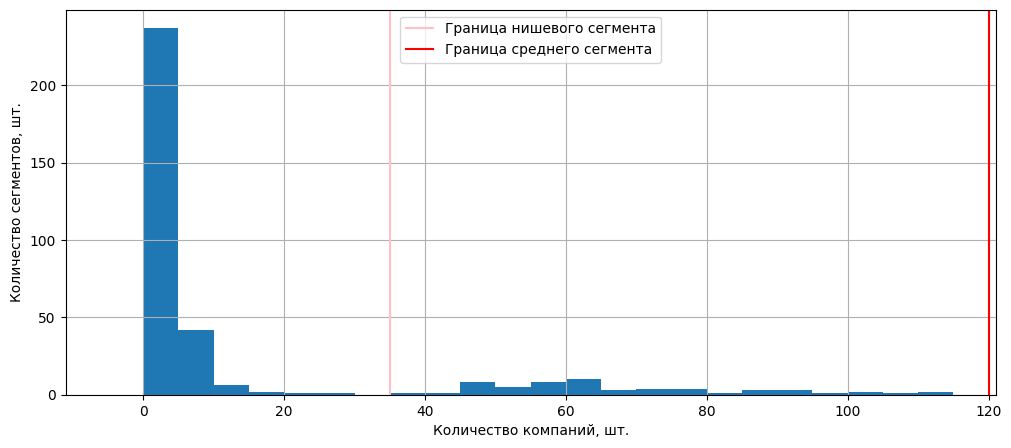

In [30]:
plt.figure(figsize=(12, 5))
market_counts.hist(bins=range(-5,120,5))
plt.axvline(35, color='pink', label='Граница нишевого сегмента')
plt.axvline(120, color='red', label='Граница среднего сегмента')
plt.legend()
plt.xlabel('Количество компаний, шт.')
plt.ylabel('Количество сегментов, шт.')

In [31]:
display(f'До замены')
display(investments_df[['name', 'market']].head())

# Создаём маппинг: название сегмента -> заглушка или оригинал
def replace_market(market_name):
    count = market_counts[market_name]
    if count > 120:
        return market_name  # оставляем как есть
    elif count >= 35:
        return 'mid'
    else:
        return 'niche'

investments_df['market'] = investments_df['market'].apply(replace_market)

display(f'После замены')
display(investments_df[['name', 'market']].head())

'До замены'

,name,market
0,Harvard University,Education
1,University of New Brunswick,unknown
2,DuPont,Business Services
3,University of Michigan,Education
4,Case Western Reserve University,Education


'После замены'

,name,market
0,Harvard University,Education
1,University of New Brunswick,unknown
2,DuPont,mid
3,University of Michigan,Education
4,Case Western Reserve University,Education


### 2.3. Промежуточный вывод после инижиниринга признаков

- Всего в данных 395 сегментов, самый большой включает в себя 4812 компаний, самый маленький - 1 компанию.
- В среднем сегмент включает 104 компании, медианное количество компаний - 3. Разница между средним и медианой составляет 101 компании, что говорит о наличии выбросов.
- 289 сегментов (73%) являются нишевыми (до 35 компаний), 57 сегментов (14%) являются средними (до 120 компаний) и 49 сегментов (14%) является массовыми (более 120 компаний).

- Подавляющее большинство сегментов рынка (73%) — нишевые: рынок стартапов
  очень фрагментирован, большинство сегментов представлены единичными компаниями.
- Массовых сегментов немного (12%), но именно они аккумулируют основной объём данных
  и будут главным объектом дальнейшего анализа.
- Средние и нишевые сегменты объединены в группы `mid` и `niche` —
  их индивидуальный анализ нецелесообразен из-за малого числа компаний.

## 3. Работа с выбросами и анализ

### 3.1. Анализируем и помечаем выбросы в каждом из сегментов

По столбцу funding_total_usd оценим, какой размер общего финансирования для одной компании будет типичным, а какой — выбивающимся.

Определим компании с аномальным объёмом общего финансирования методом IQR отдельно по каждому сегменту. Все нишевые сегменты объеденим в одну группу, а средние — в другую. Массовые сегменты оставляем как есть.

In [32]:
pd.set_option('display.float_format', '{:,.2f}'.format)
investments_df['funding_total_usd'].describe()

count           40,907.00
mean        15,912,526.05
std        168,678,800.17
min                  1.00
25%            350,000.00
50%          2,000,000.00
75%         10,000,000.00
max     30,079,503,000.00
Name: funding_total_usd, dtype: float64

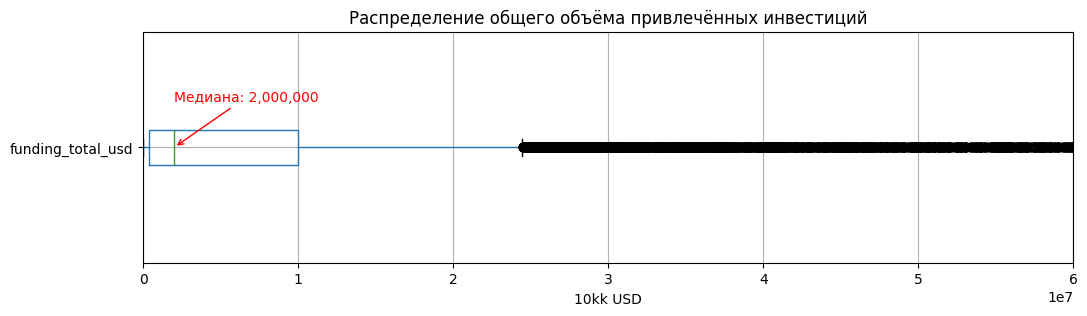

In [33]:
# Данные ограничены 95-ым процентилем.
plt.figure(figsize=(12, 3))
ax = investments_df[investments_df['funding_total_usd'].notna()].boxplot(column='funding_total_usd', vert=False)
plt.xlim(0, df['funding_total_usd'].quantile(0.95))

# Получаем значение медианы и подписываем
median = df['funding_total_usd'].median()
ax.annotate(f'Медиана: {median:,.0f}',
            xy=(median, 1),
            xytext=(median, 1.2),
            ha='left',
            arrowprops=dict(arrowstyle='->', color='red'),
            color='red')

plt.title('Распределение общего объёма привлечённых инвестиций')
plt.xlabel('10kk USD')
plt.show()

**Промежуточный вывод:** типичный общий размер финансирования для одной компании находится в диапазоне 350-10000 тыс. USD. Наиболее часто встречается финансирование на сумму в районе 2000 тыс. USD.

In [34]:
# Используем метод IQR по каждому сегменту
def detect_outliers_iqr(group):
    Q1 = group.quantile(0.25)
    Q3 = group.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return (group < lower_bound) | (group > upper_bound)

# Применяем фкнуцию с IQR к сегментам
investments_df['anomaly'] = investments_df.groupby('market')['funding_total_usd'].apply(detect_outliers_iqr)

In [35]:
def detect_outliers_iqr(group):
    Q1 = group.quantile(0.25)
    Q3 = group.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return pd.DataFrame({
        'anomaly':     (group < lower_bound) | (group > upper_bound),
        'lower_bound': lower_bound,
        'upper_bound': upper_bound
    }, index=group.index)

# Применяем функцию с IQR к сегментам
investments_df['anomaly']  = investments_df.groupby('market')['funding_total_usd'].apply(detect_outliers_iqr)

In [36]:
display(investments_df.head())

,name,homepage_url,category_list,market,funding_total_usd,status,country_code,state_code,region,city,funding_rounds,participants,founded_at,founded_month,founded_quarter,founded_year,first_funding_at,mid_funding_at,last_funding_at,seed,venture,equity_crowdfunding,undisclosed,convertible_note,debt_financing,angel,grant,private_equity,post_ipo_equity,post_ipo_debt,secondary_market,product_crowdfunding,round_A,round_B,round_C,round_D,round_E,round_F,round_G,round_H,funding_duration_days,funding_group,anomaly
0,Harvard University,http://harvard.edu,|Education|,Education,"90,000,000.00",operating,USA,MA,Boston,Cambridge,1.00,NaN,NaT,NaN,NaN,"1,636.00",2014-01-06,2014-01-06,2014-01-06,0.00,0.00,0.00,0.00,0.00,0.00,0.00,"90,000,000.00",0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,Единичное финансирование,True
1,University of New Brunswick,http://www.unb.ca,unknown,unknown,"2,000,000.00",operating,unknown,unknown,unknown,unknown,1.00,NaN,1785-01-01,NaN,NaN,"1,785.00",2014-05-15,2014-05-15,2014-05-15,0.00,"2,000,000.00",0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,Единичное финансирование,False
2,DuPont,http://www.dupont.com,|Business Services|Agriculture|Automotive|Inve...,mid,"9,000,000.00",operating,USA,DE,"Wilmington, Delaware",Wilmington,1.00,1.00,1802-07-19,NaN,NaN,"1,802.00",2009-07-02,2009-07-02,2009-07-02,0.00,"9,000,000.00",0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,Единичное финансирование,False
3,University of Michigan,http://www.umich.edu/,|Education|,Education,"7,700,000.00",operating,USA,MI,Detroit,Ann Arbor,3.00,0.00,1817-01-01,NaN,NaN,"1,817.00",2013-11-21,2013-11-21,2014-11-03,0.00,0.00,0.00,"1,600,000.00",0.00,0.00,0.00,"6,100,000.00",0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,347.00,Срок финансирования до года,False
4,Case Western Reserve University,http://www.case.edu,|Education|,Education,"540,000.00",operating,USA,OH,Cleveland,Cleveland,1.00,NaN,1826-01-01,NaN,NaN,"1,826.00",2014-01-14,2014-01-14,2014-01-14,0.00,0.00,0.00,0.00,0.00,0.00,0.00,"540,000.00",0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,Единичное финансирование,False


Топ-10 сегментов по доле компаний с аномальным финансированием:


,Всего компаний,Выбросов,"Доля, %"
market,,,
Real Estate,279,48,17.20
Entertainment,150,25,16.70
Consulting,349,58,16.60
Search,291,48,16.50
Cloud Computing,152,25,16.40
Photography,204,33,16.20
SaaS,272,44,16.20
Video,188,30,16.00
Technology,238,38,16.00


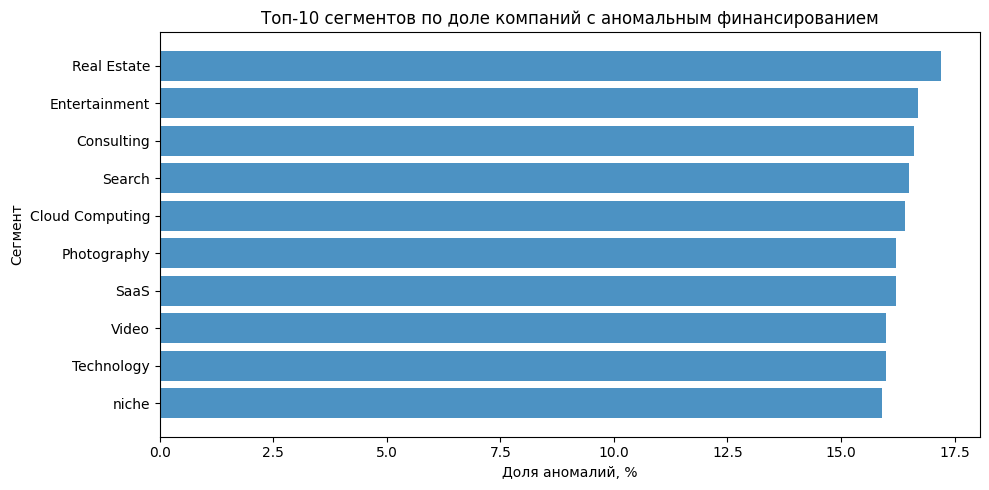

In [37]:
# Считаем количество и долю выбросов по каждому сегменту
outlier_by_market = (
    investments_df
    .groupby('market')['anomaly']
    .agg(**
         {'Всего компаний': 'count',
          'Выбросов': 'sum'}
    )
)
outlier_by_market['Доля, %'] = (
    outlier_by_market['Выбросов'] / outlier_by_market['Всего компаний'] * 100
).round(1)

top_outliers = outlier_by_market.sort_values('Доля, %', ascending=False).head(10)

print('Топ-10 сегментов по доле компаний с аномальным финансированием:')
display(top_outliers)

# Визуализация
plt.figure(figsize=(10, 5))
plt.barh(
    top_outliers.index,
    top_outliers['Доля, %'],
    alpha=0.8
)
plt.title('Топ-10 сегментов по доле компаний с аномальным финансированием')
plt.xlabel('Доля аномалий, %')
plt.ylabel('Сегмент')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

**Промежуточный вывод:** Топ-3 сегмента по доле компаний с аномальным финансированием по методу IQR:

|        market | Всего компаний | Выбросов | Доля, % |
|--------------:|------:|---------:|--------:|
|   Real Estate |   279 |       48 |   17.20 |
| Entertainment |   150 |       25 |   16.70 |
|    Consulting |   349 |       58 |   16.60 |


### 3.2 Определяем границы рассматриваемого периода, отбрасываем аномалии

Проверим, что предоставлены полные данные за 2014 год.

In [38]:
print('Максимальные даты в датасете:')
print(f'last_funding_at: {investments_df["last_funding_at"].max()}')
print(f'founded_at:      {investments_df["founded_at"].max()}')
print()

Максимальные даты в датасете:
last_funding_at: 2014-12-31 00:00:00
founded_at:      2014-12-13 00:00:00



Исключим из данных компании, получившие аномальное финансирование. Затем на основе столбцов 'mid_funding_at' и 'funding_rounds' оставим в датасете данные только об определённых компаниях. Они должны были получать финансирование в годы, когда было зафиксировано 50 или более раундов финансирования.

In [39]:
# Извлекаем год из mid_funding_at
investments_df['mid_funding_year'] = investments_df['mid_funding_at'].dt.year

rows_before = len(investments_df)

# 1. Убираем выбросы
investments_df = investments_df[investments_df['anomaly'] == False]
print(f'Удалено выбросов: {rows_before - len(investments_df)}')

# 2. Пересчитываем количество раундов по годам после удаления выбросов
rounds_by_year = investments_df.groupby('mid_funding_year')['funding_rounds'].sum().sort_index()
display(rounds_by_year)

# 3. Оставляем только годы с 50 и более раундами
active_years = rounds_by_year[rounds_by_year >= 50].index
print(f'\nАктивные годы (≥50 раундов): {sorted(active_years.tolist())}')

# 4. Фильтруем компании по активным годам
investments_df = investments_df[investments_df['mid_funding_year'].isin(active_years)]
print(f'\nСтрок после фильтрации: {len(investments_df)}')

Удалено выбросов: 5244


mid_funding_year
1,921.00        1.00
1,960.00        2.00
1,979.00        1.00
1,982.00        3.00
1,983.00        1.00
1,984.00        2.00
1,985.00        3.00
1,987.00        2.00
1,989.00        1.00
1,990.00        1.00
1,992.00        5.00
1,993.00        1.00
1,994.00        4.00
1,995.00        9.00
1,996.00        8.00
1,997.00        5.00
1,998.00       15.00
1,999.00       43.00
2,000.00      113.00
2,001.00       66.00
2,002.00       98.00
2,003.00      125.00
2,004.00      181.00
2,005.00      948.00
2,006.00    1,849.00
2,007.00    2,842.00
2,008.00    3,663.00
2,009.00    4,617.00
2,010.00    6,136.00
2,011.00    7,578.00
2,012.00    9,707.00
2,013.00   12,880.00
2,014.00    7,122.00
Name: funding_rounds, dtype: float64


Активные годы (≥50 раундов): [2000.0, 2001.0, 2002.0, 2003.0, 2004.0, 2005.0, 2006.0, 2007.0, 2008.0, 2009.0, 2010.0, 2011.0, 2012.0, 2013.0, 2014.0]

Строк после фильтрации: 35588


**Промежуточные выводы**:
    - в датасете есть данные за полный 2014г.;
    - исключены компании с аномальным объемом финансирования;
    - исключены компании, которые получали финансирование в годах, где было меньше 50 раундов.

### 3.3. Анализ типов финансирования по объёму и популярности

Построим график, который покажет, какие типы финансирования в сумме привлекли больше всего денег. Ориентироваться будем на значения в столбцах seed, venture, equity_crowdfunding, undisclosed, convertible_note, debt_financing, angel, grant, private_equity, post_ipo_equity, post_ipo_debt, secondary_market и product_crowdfunding.

In [40]:
funding_types = [
    'seed', 'venture', 'equity_crowdfunding', 'undisclosed',
    'convertible_note', 'debt_financing', 'angel', 'grant',
    'private_equity', 'post_ipo_equity', 'post_ipo_debt',
    'secondary_market', 'product_crowdfunding'
]

# Суммарный объём финансирования
funding_totals = investments_df[funding_types].sum().sort_values(ascending=True) / 1000000

# Популярность — количество компаний с ненулевым значением по каждому типу
funding_popularity = (investments_df[funding_types] > 0).sum().sort_values(ascending=True)

funding_stats = pd.DataFrame({
    'Суммарный объём финансирования, млн USD': funding_totals,
    'Доля объёма, %':   (funding_totals   / funding_totals.sum()     * 100).round(1),
    'Популярность, кол-во компаний': funding_popularity,
    'Доля популярности, %': (funding_popularity / funding_popularity.sum() * 100).round(1),
})

display(funding_stats.sort_values('Суммарный объём финансирования, млн USD', ascending=False))

,"Суммарный объём финансирования, млн USD","Доля объёма, %","Популярность, кол-во компаний","Доля популярности, %"
venture,"129,092.21",80.00,18820,44.50
seed,"9,431.33",5.80,13375,31.60
debt_financing,"8,178.15",5.10,3265,7.70
private_equity,"4,843.11",3.00,634,1.50
angel,"2,481.26",1.50,2937,6.90
undisclosed,"2,100.35",1.30,813,1.90
grant,"1,978.85",1.20,1003,2.40
post_ipo_equity,"1,946.45",1.20,164,0.40
convertible_note,566.04,0.40,521,1.20
post_ipo_debt,286.72,0.20,27,0.10


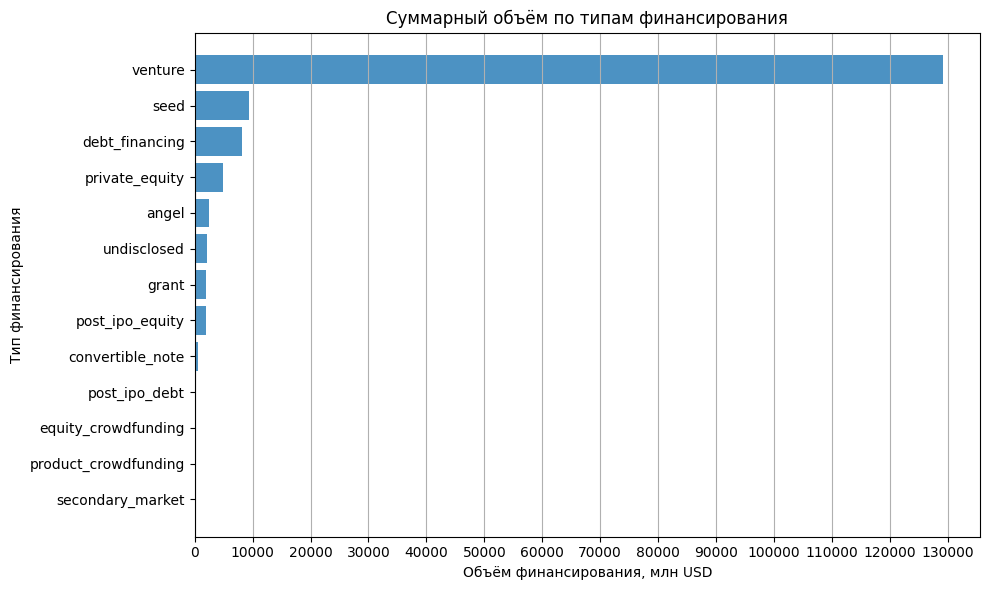

In [41]:
# График с объемами финансирования
plt.figure(figsize=(10, 6))
plt.barh(funding_totals.index, funding_totals.values, alpha=0.8)
plt.title('Суммарный объём по типам финансирования')
plt.xlabel('Объём финансирования, млн USD')
plt.ylabel('Тип финансирования')

plt.xticks(range(0, int(funding_totals.max()) + 10_000, 10_000))
plt.grid(axis='x')

plt.tight_layout()
plt.show()

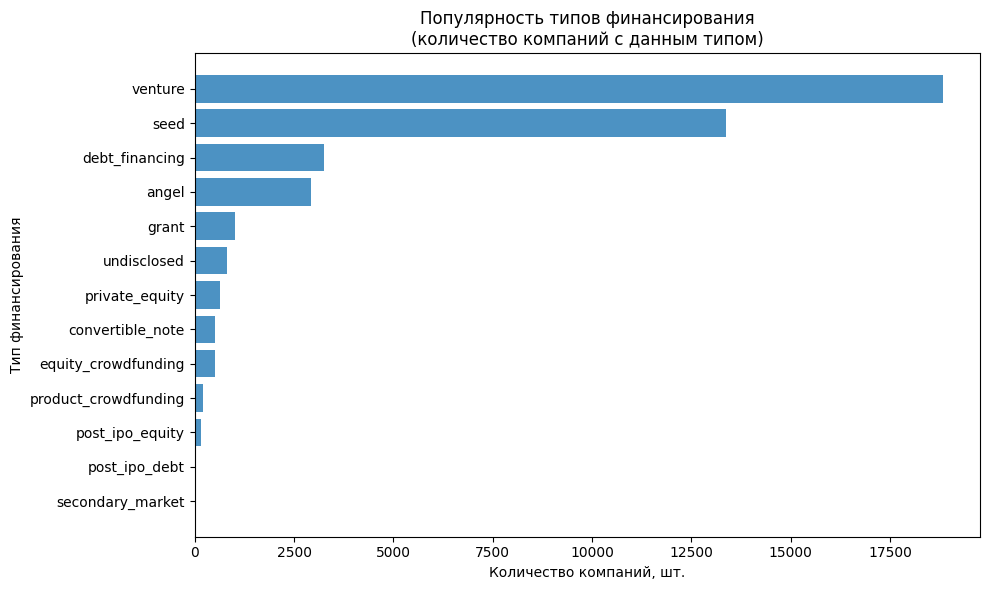

In [42]:
# График с популярностью
plt.figure(figsize=(10, 6))
plt.barh(funding_popularity.index, funding_popularity.values, alpha=0.8)
plt.title('Популярность типов финансирования\n(количество компаний с данным типом)')
plt.xlabel('Количество компаний, шт.')
plt.ylabel('Тип финансирования')
plt.tight_layout()
plt.show()

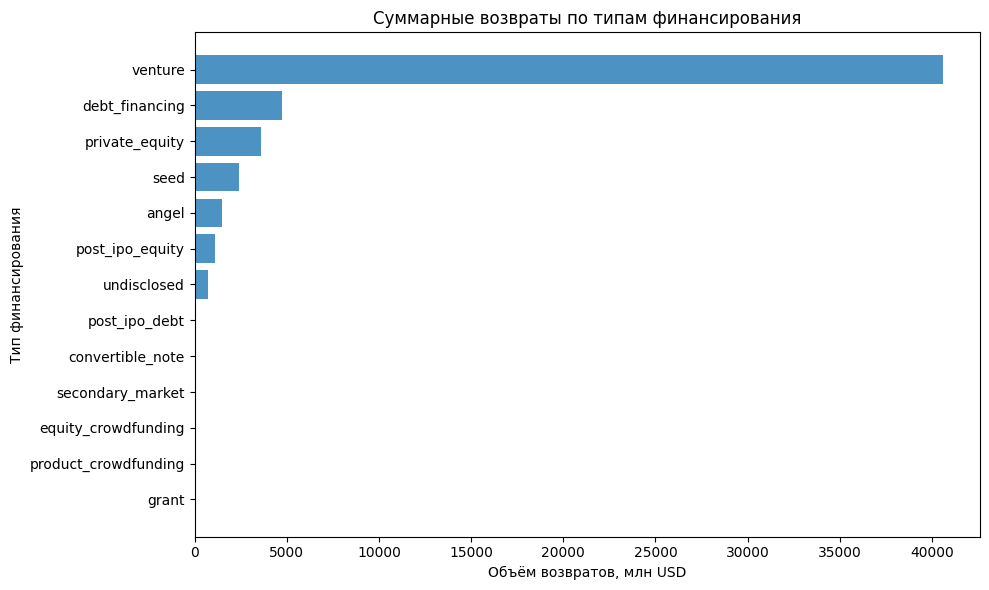

In [43]:
returns_totals = returns_df[funding_types].sum().sort_values(ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(returns_totals.index, returns_totals.values, alpha=0.8)
plt.title('Суммарные возвраты по типам финансирования')
plt.xlabel('Объём возвратов, млн USD')
plt.ylabel('Тип финансирования')
plt.tight_layout()
plt.show()

### 3.4. Промежуточный вывод
- Медианный размер инвестиций в одну компанию составляет  2,000,000 USD.
- Провели отчистку данных, и оставили данные только за 2000-2014гг., в которых было больше 50 раундов финансирования.
- Самым  популярным типом финансирования с точки зрения частоты использования и объемов являются венчурные инвестиции (venture). К ним относятся 80% всех инвестиций (129,092 млн.USD) и 44.5% компаний (18820 шт.).
- Вторым часто используемым типом финансирования, который при этом характеризуется небольшим объемом является инвестирование на посевной стадии (seed). К этому типу относится 6% всех инвестиций (9,431 млн.USD) и 31.6% компаний (13375 шт.).
- Типы финанисрования, которые встречаются редко, но при этом характеризуются значительным объёмом финанисрования:
    - долговое финансирование (debt_financing): 5% всех инвестиций (8,178 млн.USD) и 7.7% компаний (3265 шт.).
    - прямые (частные) вложения (private_equity): 3% всех инвестиций (4,843 млн.USD) и 1.5% компаний (634 шт.).
    - бизнес-ангелы (angel): 2% всех инвестиций (2,481 млн.USD) и 6.9% компаний (2937 шт.).


## 4. Анализ динамики

### 4.1 Динамика предоставления финансирования по годам

Используя столбцы `funding_total_usd` и `funding_rounds` для каждой компании рассчитаем средний объём одного раунда финансирования. Построим графики, которые отразят:
- динамику типичного размера средств, которые стартапы получали в рамках одного раунда финансирования;
- динамику общего количества раундов за каждый год, то есть насколько активно происходили инвестиции на рынке (чем больше раундов, тем выше активность).

In [44]:
# Делим общее финансирование на количество раундов.
investments_df['avg_round_usd'] = (
    investments_df['funding_total_usd'] / (investments_df['funding_rounds'])
)

print('Статистика среднего объёма одного раунда, USD:')
print(investments_df['avg_round_usd'].describe().apply(lambda x: f'{x:,.0f}'))

Статистика среднего объёма одного раунда, USD:
count        35,588
mean      2,786,692
std       4,974,836
min               1
25%         200,000
50%       1,000,000
75%       3,200,000
max      70,000,000
Name: avg_round_usd, dtype: object


mid_funding_year
2,000.00   2.25
2,001.00   1.57
2,002.00   3.23
2,003.00   1.50
2,004.00   3.00
2,005.00   4.50
2,006.00   3.90
2,007.00   2.88
2,008.00   2.17
2,009.00   1.50
2,010.00   1.25
2,011.00   0.87
2,012.00   0.69
2,013.00   0.56
2,014.00   0.56
Name: avg_round_usd, dtype: float64

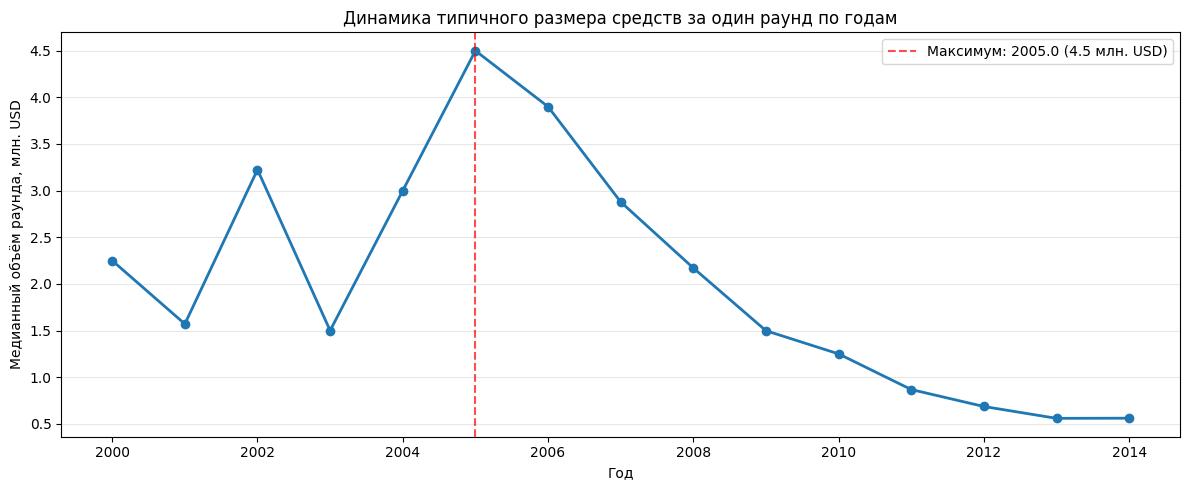

In [45]:
# Группируем по году среднего раунда финансирования.
# Используем медиану как «типичный размер» — она устойчива к выбросам,
# в отличие от среднего арифметического.
median_round_by_year = (
    investments_df
    .groupby('mid_funding_year')['avg_round_usd']
    .median()
    .sort_index()
    / 1e6  # переводим в млн USD для читаемости
)

display(median_round_by_year)

plt.figure(figsize=(12, 5))
plt.plot(median_round_by_year.index, median_round_by_year.values,
         marker='o', linewidth=2, markersize=6)

# Выделяем год с максимальным значением
max_year  = median_round_by_year.idxmax()
max_value = median_round_by_year.max()
plt.axvline(max_year, color='red', linestyle='--', alpha=0.7,
            label=f'Максимум: {max_year} ({max_value:.1f} млн. USD)')

plt.title('Динамика типичного размера средств за один раунд по годам')
plt.xlabel('Год')
plt.ylabel('Медианный объём раунда, млн. USD')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

mid_funding_year
2,000.00      113.00
2,001.00       66.00
2,002.00       98.00
2,003.00      125.00
2,004.00      181.00
2,005.00      948.00
2,006.00    1,849.00
2,007.00    2,842.00
2,008.00    3,663.00
2,009.00    4,617.00
2,010.00    6,136.00
2,011.00    7,578.00
2,012.00    9,707.00
2,013.00   12,880.00
2,014.00    7,122.00
Name: funding_rounds, dtype: float64

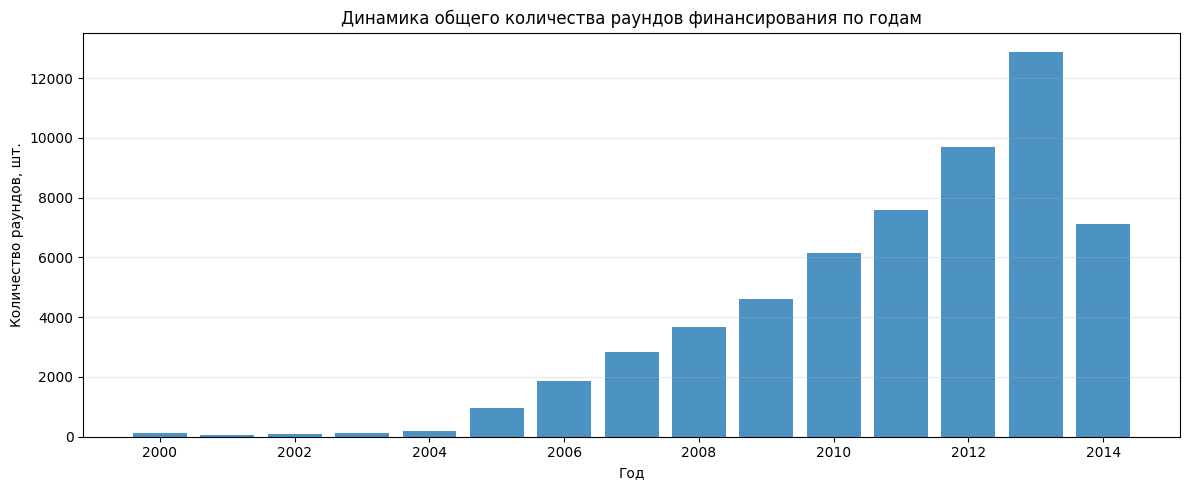

In [46]:
# Суммируем количество раундов всех компаний по году как индикатор общей инвестиционной активности рынка.
rounds_by_year = (
    investments_df
    .groupby('mid_funding_year')['funding_rounds']
    .sum()
    .sort_index()
)
display(rounds_by_year)

plt.figure(figsize=(12, 5))
plt.bar(rounds_by_year.index, rounds_by_year.values, alpha=0.8)

plt.title('Динамика общего количества раундов финансирования по годам')
plt.xlabel('Год')
plt.ylabel('Количество раундов, шт.')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

**Промежуточные выводы:**
- Максимальный типичный размер средств, собранных в рамках одного раунда, был в 2005 году - 4.5 млн. USD. После этого медианный объём раундов ежегодно снижался.
- В 2014г. по сравнению с 2013г. количество раундов сократилось на 5758 (45%), а размер средств выделяемых за один раунд составил 0.56 млн. USD - это минимум за 15 лет, по которым есть данные.

### 4.2 Динамика размера общего финансирования по массовым сегментам рынка для растущих в 2014 году сегментов

Составим сводную таблицу, в которой указывается суммарный размер общего финансирования `funding_total_usd` по годам и сегментам рынка. Отберем из неё только те сегменты, которые показывали рост размера суммарного финансирования в 2014 году по сравнению с 2013.

In [47]:
# Оставляем только массовые сегменты — mid и niche исключаем
mass_df = investments_df[~investments_df['market'].isin(['mid', 'niche', 'unknown'])]

# Строим сводную таблицу: строки — сегменты рынка, столбцы — годы,
# значения — суммарный объём финансирования в млн USD
pivot = (
    mass_df
    .groupby(['mid_funding_year', 'market'])['funding_total_usd']
    .sum()
    .unstack('mid_funding_year')
    .fillna(0)
    / 1000000
)

print('Сводная таблица: суммарное финансирование по сегментам и годам, млн USD')
display(pivot)

Сводная таблица: суммарное финансирование по сегментам и годам, млн USD


mid_funding_year,"2,000.00","2,001.00","2,002.00","2,003.00","2,004.00","2,005.00","2,006.00","2,007.00","2,008.00","2,009.00","2,010.00","2,011.00","2,012.00","2,013.00","2,014.00"
market,,,,,,,,,,,,,,,
Advertising,14.47,8.78,24.50,10.50,6.00,127.20,299.30,556.70,622.67,563.45,631.62,410.73,521.14,524.92,207.79
Analytics,14.82,0.00,7.50,3.84,3.00,79.01,139.70,98.83,208.08,140.95,253.74,443.33,539.21,622.82,151.46
Apps,0.00,0.00,0.00,0.00,0.00,0.00,1.31,0.00,4.30,7.22,6.12,18.37,32.60,28.87,66.24
Automotive,0.00,0.00,0.00,4.53,0.00,22.50,12.66,37.71,59.48,20.80,17.70,76.45,35.56,117.57,69.03
Big Data,0.00,0.00,0.00,0.00,0.00,0.00,0.00,7.78,2.45,0.60,39.23,60.37,86.41,78.70,79.23
Biotechnology,0.00,0.00,0.00,85.53,97.18,480.06,903.50,"1,704.08","1,716.03","3,915.90","4,894.50","4,967.55","4,931.14","5,694.27","2,509.64"
Clean Technology,0.00,0.00,34.39,50.35,50.43,19.42,131.47,749.71,"3,165.81","1,963.50","1,604.43","1,545.60",958.01,"1,203.06",688.69
Cloud Computing,11.50,0.00,0.00,0.00,0.00,0.00,9.95,20.35,44.38,52.22,8.53,73.15,74.42,84.85,73.44
Consulting,4.50,0.00,0.00,0.00,0.00,44.86,23.97,70.35,19.06,62.72,81.26,43.41,65.92,93.32,54.30


In [48]:
# Сравниваем суммарное финансирование в 2014 и 2013 годах.
# Отбираем сегменты, где в 2014 году объём вырос относительно 2013-го.
if 2014 in pivot.columns and 2013 in pivot.columns:
    growth_2014 = pivot[2014] - pivot[2013]
    growth_2014_pct = growth_2014 / pivot[2013] * 100
    growing_segments = growth_2014[growth_2014 > 0].index.tolist()
else:
    raise ValueError('Годы 2013 или 2014 отсутствуют в данных после фильтрации')

print('Рост финансирования в 2014 vs 2013:')

growth_stats = pd.DataFrame({
    'Объём 2013, млн. USD':  pivot[2013],
    'Объём 2014, млн. USD':  pivot[2014],
    'Прирост, млн. USD':     growth_2014,
    'Прирост, %':           growth_2014_pct.round(1),
})

display(
    growth_stats[growth_2014 > 0]
    .sort_values('Прирост, млн. USD', ascending=False)
    .style.format({
        'Объём 2013, млн. USD': '{:,.1f}',
        'Объём 2014, млн. USD': '{:,.1f}',
        'Прирост, млн. USD':    '+{:,.1f}',
        'Прирост, %':          '+{:.1f}%',
    })
)

Рост финансирования в 2014 vs 2013:


,"Объём 2013, млн. USD","Объём 2014, млн. USD","Прирост, млн. USD","Прирост, %"
market,,,,
Medical,64.5,175.2,+110.8,+171.8%
Technology,120.9,202.0,+81.1,+67.1%
Internet,69.7,117.8,+48.1,+69.0%
Apps,28.9,66.2,+37.4,+129.4%
Startups,18.1,41.5,+23.4,+129.5%
Real Estate,92.2,115.6,+23.4,+25.3%
Manufacturing,393.9,416.3,+22.4,+5.7%
SaaS,79.6,92.8,+13.2,+16.6%
Design,61.0,69.0,+8.0,+13.2%


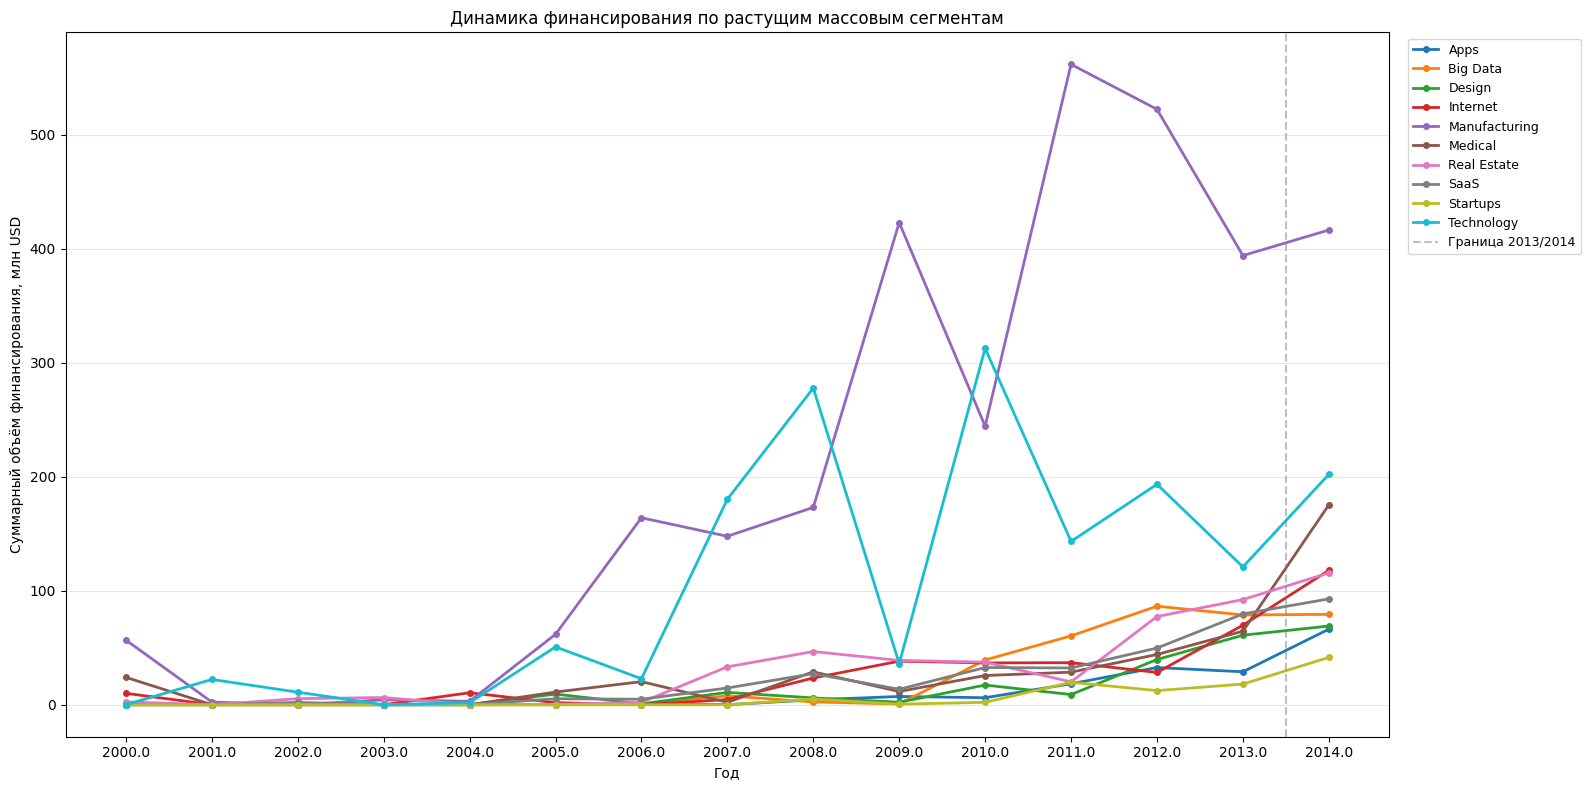

In [49]:
# Транспонируем pivot: строки — годы, столбцы — сегменты
# Оставляем только растущие сегменты и период с 2005 года
pivot_growing = pivot.loc[growing_segments].T

# Выбираем цветовую палитру под количество сегментов
colors_segments = sns.color_palette('tab10', n_colors=len(growing_segments))

plt.figure(figsize=(16, 8))
for i, segment in enumerate(growing_segments):
    plt.plot(
        pivot_growing.index,
        pivot_growing[segment],
        marker='o',
        markersize=4,
        linewidth=2,
        label=segment,
        color=colors_segments[i]
    )

# Вертикальная линия — граница 2013/2014
plt.axvline(2013.5, color='grey', linestyle='--', alpha=0.5, label='Граница 2013/2014')

plt.title('Динамика финансирования по растущим массовым сегментам')
plt.xlabel('Год')
plt.xticks(
    ticks=pivot_growing.index,
    labels=pivot_growing.index,
    rotation=0
)
plt.ylabel('Суммарный объём финансирования, млн USD')
plt.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

**Промежуточные выводы:**
- Топ-3 сегмента, которые показывают наиболее быстрый и уверенный рост:
|        market | Прирост, млн. USD | Прирост, % |
|--------------:|------------------:|-----------:|
|       Medical |            +110.8 |    +171.8% |
|          Apps |             +37.4 |    +129.4% |
|      Startups |             +23.4 |    +129.5% |
- Топ-3 сегмента, которые показывают самый медленный рост:
|        market | Прирост, млн. USD | Прирост, % |
|--------------:|------------------:|-----------:|
| Manufacturing |             +22.4 |      +5.7% |
|        Design |              +8.0 |     +13.2% |
|      Big Data |              +0.5 |      +0.7% |
- Сегменты Manufacturing и Technology имеют резкие скачки объмов финанисрования в прошлом (2008-2011гг.), соответственно они менее предсказуемы и несут более высокий инвестиционный риск.

### 4.3 Годовая динамика доли возвращённых средств по типам финансирования

Для каждого года и каждого вида финансирования рассчитаем нормированные значения возврата средств: то есть какую долю возвращённые средства составляют от предоставленных. При этом слишком большие аномальные значения, то есть неадекватные выбросы, заменим на пропуски.

Постром график, на котором отобразим нормированные значения возврата средств для типов финансирования venture, debt_financing, private_equity, seed и angel.

In [50]:
# Все типы финансирования уже есть в переменной funding_types
# Считаем суммарный объём финансирования по годам и всем типам
invested = (
    investments_df
    .groupby('mid_funding_year')[funding_types]
    .sum()
    / 1000000
)

returned = returns_df[funding_types]

# Рассчитываем нормированные возвраты по всем типам.
# 1e-60 - защита от деления на ноль.
norm_returns = returned / (invested + 1e-60)

# Заменяем аномальные значения (> 1 или отрицательные) на NaN —
# т.к. невозможно вернуть больше, чем вложено в рамках одного года
norm_returns = norm_returns.where(
    (norm_returns >= 0) & (norm_returns <= 1)
)

print('Нормированные возвраты по всем типам финансирования:')
display(norm_returns.round(3))

Нормированные возвраты по всем типам финансирования:


,seed,venture,equity_crowdfunding,undisclosed,convertible_note,debt_financing,angel,grant,private_equity,post_ipo_equity,post_ipo_debt,secondary_market,product_crowdfunding
year,,,,,,,,,,,,,
2000,1.00,0.17,0.00,0.70,0.00,0.62,0.27,0.00,0.00,0.27,0.00,0.03,0.00
2001,NaN,0.11,0.00,0.59,0.01,0.77,NaN,0.00,0.00,NaN,0.00,NaN,0.00
2002,0.63,0.68,0.00,0.61,NaN,0.22,NaN,0.00,0.20,NaN,0.00,NaN,0.00
2003,0.51,0.63,0.00,0.91,NaN,NaN,0.61,0.00,NaN,NaN,0.00,NaN,0.00
2004,0.55,0.84,0.00,0.53,NaN,0.44,0.83,0.00,NaN,NaN,0.00,NaN,0.00
2005,0.68,0.55,0.00,NaN,NaN,0.34,0.51,0.00,0.48,0.73,0.00,NaN,0.00
2006,0.93,0.34,0.20,0.76,0.17,0.80,0.68,0.00,0.94,NaN,0.00,NaN,0.00
2007,0.37,0.30,NaN,0.51,0.23,0.60,0.82,0.00,0.58,NaN,0.00,NaN,0.00
2008,0.30,0.19,NaN,0.34,0.06,0.93,0.41,0.00,0.68,NaN,0.00,NaN,0.00


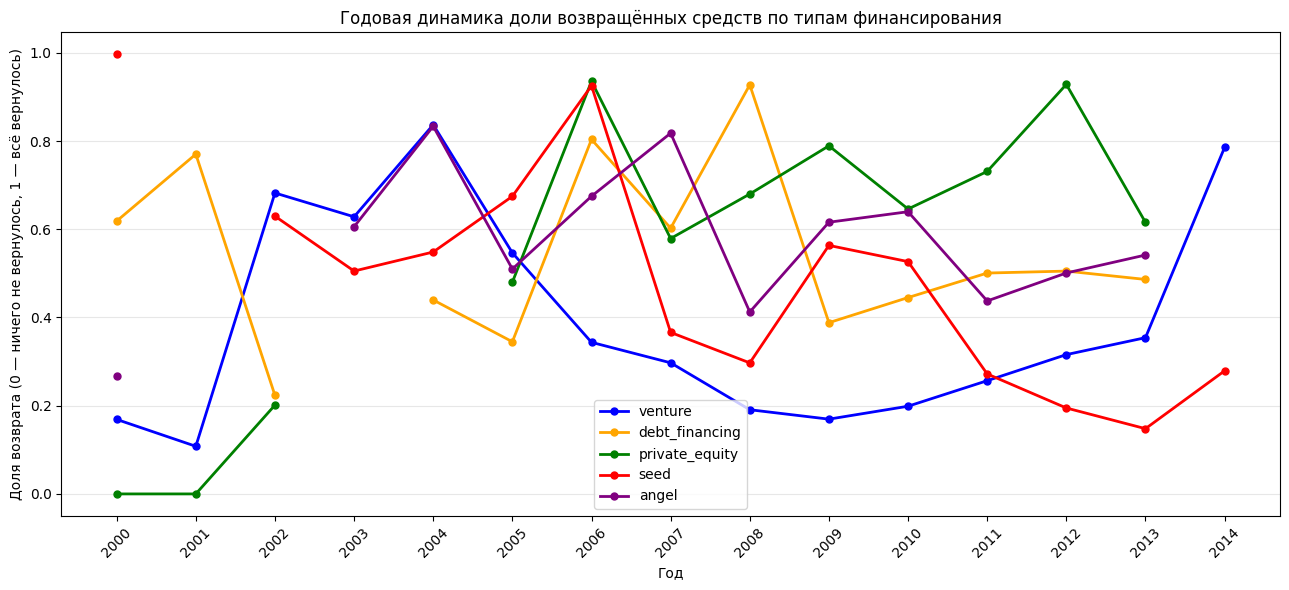

In [55]:
# Типы для графика — только пять ключевых
plot_types = ['venture', 'debt_financing', 'private_equity', 'seed', 'angel']

# Типы для графика — только пять ключевых
plot_types = ['venture', 'debt_financing', 'private_equity', 'seed', 'angel']

colors_returns = {
    'venture':         'blue',
    'debt_financing':  'orange',
    'private_equity':  'green',
    'seed':            'red',
    'angel':           'purple',
}

plt.figure(figsize=(13, 6))

for col in plot_types:
    series = norm_returns[col]
    plt.plot(
        series.index,
        series.values,
        marker='o',
        markersize=5,
        linewidth=2,
        label=col,
        color=colors_returns[col]
    )

plt.title('Годовая динамика доли возвращённых средств по типам финансирования')
plt.xlabel('Год')
plt.ylabel('Доля возврата (0 — ничего не вернулось, 1 — всё вернулось)')
plt.xticks(ticks=norm_returns.index, labels=norm_returns.index, rotation=45)
plt.legend(fontsize=10)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

**Промужуточный вывод:** наиболее устойчивый рост показателя возравратов за последние 5 лет наблюдается у венчурного финансирования (venture). В 2014 он составил 0.79, то есть 79% инвестиций вложенных в этом году были возвращены. При этом этот тип финансирования явлется самым популярным по частоте использования и объемов инвестиций, что говорит о его стабильности и надежности.

### 4.4. Промежуточный вывод

- Объем средств выделяемых за один раунд падает, начиная с 2005г., но при этом до 2014г. росло количество проводимых раундов.
- Medical, Apps, Startups - самые быстрорастующие массовые сегменты.
- Наиболее устойчивый рост показателя возравратов за последние 5 лет наблюдается у венчурного финансирования (venture). В 2014 он составил 0.79, то есть 79% инвестиций вложенных в этом году были возвращены. При этом этот тип финансирования явлется самым популярным по частоте использования и объемов инвестиций, что говорит о его стабильности и надежности.

## 5. Итоговый вывод и рекомендации

#### Выполненные шаги

В ходе исследования были пройдены следующие шаги:
1. **Предобработка данных.** Загружены и очищены два датасета: `cb_investments` (54 294 → 40 907 строк) и `cb_returns`. Исправлены типы данных, устранены дубликаты, обработаны пропуски. Восстановлены пропущенные значения `mid_funding_at` через середину интервала между первым и последним раундом.

2. **Инжиниринг признаков.** Компании разделены на три группы по срокам финансирования. Сегменты рынка классифицированы на массовые (49 сегм.), средние (57 сегм.) и нишевые (289 сегм.); Последние два были объединены в две группы `mid` и `niche` соответственно.

3. **Работа с выбросами.** Выбросы определены методом IQR отдельно по каждому сегменту (удалено 5 244 компании). Данные ограничены периодом 2000–2014 годов (в этих годаъ более 50 раундов). Проведён анализ типов финансирования: по объёму и популярности лидирует venture, по доле аномально профинансированных компаний — Real Estate, Entertainment и Consulting.

4. **Анализ динамики.** Исследована динамика медианного объёма раунда и количества раундов по годам. Составлена сводная таблица по сегментам и годам, отобраны растущие в 2014 году сегменты. Рассчитаны нормированные возвраты по типам финансирования.

#### Выводы, которые удалось сделать

- **Структура финансирования.** 59% компаний получили единичное финансирование, однако основной объём средств (62%) сосредоточен у компаний с многолетним сопровождением — они привлекают крупные, многораундовые инвестиции.
- **Рынок фрагментирован.** 73% сегментов являются нишевыми, реальная конкуренция за инвестиции сосредоточена в 49 массовых сегментах.
- **Активность растёт, размер раунда падает.** Медианный объём одного раунда снижается с 2005 года (пик — 4.5 млн USD), однако количество раундов уверенно росло вплоть до 2013 года. Это говорит о демократизации рынка: деньги распределяются шире, но меньшими порциями.
- **Venture доминирует.** 80% всех инвестиций приходится на венчурное финансирование, и именно оно показывает наиболее устойчивый рост возвратности.
- **Быстрорастущие сегменты** в 2014 году — Medical, Apps, Startups.

#### В какую отрасль стоит инвестировать?

Анализ динамики финансирования по массовым сегментам рынка показал, что в 2014 году относительно 2013-го наиболее уверенный рост продемонстрировали три сегмента:

| Сегмент | Прирост, млн USD | Прирост, % |
|--------:|----------------:|-----------:|
| Medical | +110.8 | +171.8% |
| Apps | +37.4 | +129.4% |
| Startups | +23.4 | +129.5% |

**Рекомендуемая отрасль — Medical (медицина и медицинские технологии).**

Аргументы в пользу этого выбора:
- Самый высокий абсолютный прирост объёма финансирования в 2014 году (+110.8 млн USD) при одновременно высоком относительном росте (+171.8%).
- Сегмент является массовым — в нём достаточно компаний для диверсификации портфеля.
- Рост носит уверенный, а не скачкообразный характер: в отличие от Manufacturing и Technology, которые демонстрировали резкие колебания в 2008–2011 годах, Medical показывает устойчивую восходящую динамику в последние годы.

**Альтернативные варианты — Apps и Startups.** Оба сегмента демонстрируют сопоставимый относительный рост (~129%), однако абсолютные объёмы финансирования в них ниже, чем в Medical.

Сегменты **Manufacturing** и **Big Data**, несмотря на присутствие в списке растущих, показывают минимальный прирост (5.7% и 0.7% соответственно) и **не рекомендуются** для приоритетного инвестирования.

---

#### Какой тип финансирования наиболее уместен?

По совокупности факторов наиболее предпочтительным типом финансирования является **венчурное (venture)**.

Обоснование:
- **Объём и популярность.** Venture — безусловный лидер: 80% всех инвестиций (129 092 млн USD) и 44.5% компаний (18 820 шт.). Это свидетельствует о эффективности инструмента.
- **Возвратность.** Наиболее устойчивый рост доли возвращённых средств за последние 5 лет наблюдается именно у венчурного финансирования. В 2014 году показатель достиг 0.79 — то есть 79% вложенных средств были возвращены, что является рекордным значением за весь период наблюдений.
- **Соответствие отрасли.** Medical — зрелый массовый сегмент с длинным горизонтом роста. Венчурное финансирование органично подходит для компаний на стадиях роста и расширения, характерных для этой отрасли.